In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
!pip install kaggle
import os
from google.colab import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('Kaggle_Username')
os.environ['KAGGLE_KEY'] = userdata.get('Kaggle_Key')


In [3]:
!kaggle datasets download adilmubashirchaudhry/plant-village-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/adilmubashirchaudhry/plant-village-dataset
License(s): CC-BY-NC-SA-4.0
100% 989M/989M [00:28<00:00, 36.2MB/s]



In [4]:
from torchvision import datasets
from torchvision import transforms
data_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),(0.229, 0.224, 0.225))
])
train_data = datasets.ImageFolder('PlantVillageDataset/train_val_test/train',transform=data_transform)
val_data = datasets.ImageFolder('PlantVillageDataset/train_val_test/val',transform=data_transform)
print(len(train_data),len(val_data))
print(train_data.classes)
print(len(train_data.classes))
# total_data = datasets.ImageFolder('PlantVillageDataset/PlantVillage')
# print(len(total_data))


14437 2073
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
15


In [5]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_data,batch_size=32,shuffle=True)
val_loader = DataLoader(val_data,batch_size=32,shuffle=False)


In [6]:
import torch.nn as nn
from torchvision import models
model = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)
for param in model.parameters():
  param.requires_grad = False
Features_Count = model.fc.in_features
model.fc = nn.Sequential(nn.Dropout(p=0.5),nn.Linear(Features_Count,15))
model = model.to(device)




Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters() , lr = 0.001)

## **No need to run this cell again**

In [8]:
# from tqdm import tqdm
# for epoch in range(5):
#   final_loss = 0.0
#   for images, labels in tqdm(train_loader):
#     images = images.to(device)
#     labels = labels.to(device)
#     optimizer.zero_grad()
#     output = model(images)
#     loss = criterion(output,labels)
#     loss.backward()
#     optimizer.step()

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# from google.colab import files
# uploaded = files.upload()

In [11]:
#torch.save(model.state_dict(), '/content/drive/MyDrive/plant_disease_resnet18.pth')

In [12]:
model.load_state_dict(torch.load('/content/drive/MyDrive/plant_disease_resnet18.pth'))

<All keys matched successfully>

In [13]:
from collections import Counter
def mc_dropout_predict(image, n_passes=30):
    model.eval()  # start in eval mode (BatchNorm stays correct/frozen)
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()  # but selectively turn Dropout back on

    image = image.unsqueeze(0).to(device)
    predictions = []
    with torch.no_grad():
        for i in range(n_passes):
            output = model(image)
            _, predicted_class = torch.max(output, dim=1)
            predictions.append(predicted_class.item())

    model.eval()  # reset everything to normal eval mode when done

    counts = Counter(predictions)
    most_common_class, most_common_count = counts.most_common(1)[0]
    confidence_score = most_common_count / n_passes

    return most_common_class, confidence_score


for i in range(15):

      image, true_label = val_data[i]
      print(mc_dropout_predict(image))

correct = 0
total = 0

with torch.no_grad():  # don't track gradients, we're not training here
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)  # shape: [batch_size, 15] - raw scores per class
        _, predicted = torch.max(outputs, dim=1)  # get the index of the highest score per image

        total += labels.size(0)  # add this batch's image count to the running total
        correct += (predicted == labels).sum().item()  # count how many predictions matched the true label


accuracy = correct / total
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

(0, 0.8)
(0, 1.0)
(1, 0.6666666666666666)
(0, 0.9)
(0, 0.5)
(1, 0.9)
(0, 0.8)
(0, 1.0)
(1, 0.9)
(0, 0.5666666666666667)
(0, 0.6333333333333333)
(0, 0.9333333333333333)
(0, 0.8666666666666667)
(0, 1.0)
(0, 1.0)
Validation Accuracy: 90.55%


In [14]:
# from PIL import Image

# img = Image.open("tomato_late_blight_0020.jpg").convert("RGB")
# img_tensor = data_transform(img)

# predicted_class, confidence = mc_dropout_predict(img_tensor)
# class_name = train_data.classes[predicted_class]

# print(f"Predicted: {class_name}")
# print(f"Confidence: {confidence:.2f}")

In [15]:
!kaggle datasets download nirmalsankalana/plantdoc-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset
License(s): CC0-1.0
100% 896M/896M [00:27<00:00, 34.5MB/s]



In [16]:
# os.listdir('train')

In [17]:
import os
from PIL import Image
folder_path = "train/Corn_rust_leaf"
image_files = os.listdir(folder_path)
ood_images = []

for filename in image_files[:20]:
    img = Image.open(os.path.join(folder_path, filename)).convert("RGB")

    image_tensor = data_transform(img)
    ood_images.append(image_tensor)
print(f"Loaded {len(ood_images)} OOD images")

Loaded 20 OOD images


In [18]:
import os
from PIL import Image
folder_path = "train/Apple_leaf"
image_files = os.listdir(folder_path)
ood_images1 = []

for filename in image_files[:20]:
    img = Image.open(os.path.join(folder_path, filename)).convert("RGB")

    image_tensor = data_transform(img)
    ood_images1.append(image_tensor)
print(f"Loaded {len(ood_images)} OOD images")

Loaded 20 OOD images


In [19]:
import os
from PIL import Image
folder_path = "train/grape_leaf"
image_files = os.listdir(folder_path)
ood_images2 = []

for filename in image_files[:20]:
    img = Image.open(os.path.join(folder_path, filename)).convert("RGB")

    image_tensor = data_transform(img)
    ood_images2.append(image_tensor)
print(f"Loaded {len(ood_images)} OOD images")

Loaded 20 OOD images


In [36]:
def get_avg_confidence(image_list):
    confidences = []
    for img_tensor in image_list:
        _, confidence = mc_dropout_predict(img_tensor)
        confidences.append(confidence)
    return sum(confidences) / len(confidences)

corn_avg = get_avg_confidence(ood_images)          # adjust variable names to match yours
apple_avg = get_avg_confidence(ood_images1)
grape_avg = get_avg_confidence(ood_images2)

print(f"Corn (unfamiliar) avg confidence: {corn_avg:.3f}")
print(f"Apple (unfamiliar) avg confidence: {apple_avg:.3f}")
print(f"Grape (unfamiliar) avg confidence: {grape_avg:.3f}")

Corn (unfamiliar) avg confidence: 0.570
Apple (unfamiliar) avg confidence: 0.565
Grape (unfamiliar) avg confidence: 0.643


In [20]:
# os.listdir('test')

In [21]:
# os.listdir('PlantVillageDataset/train_val_test/train')


In [22]:
class_mapping = {
    "Tomato__Tomato_mosaic_virus":"Tomato_leaf_mosaic_virus",
    "Tomato_Late_blight":"Tomato_leaf_late_blight",
    "Tomato_Early_blight":"Tomato_Early_blight_leaf",
    "Tomato_Leaf_Mold":"Tomato_mold_leaf",
    "Tomato_Septoria_leaf_spot":"Tomato_Septoria_leaf_spot",
    "Potato___Late_blight":"Potato_leaf_late_blight",
    "Tomato__Tomato_YellowLeaf__Curl_Virus":"Tomato_leaf_yellow_virus",
    "Potato___Early_blight":"Potato_leaf_early_blight",
    "Tomato_healthy":"Tomato_leaf",
    "Tomato_Bacterial_spot":"Tomato_leaf_bacterial_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite":"Tomato_two_spotted_spider_mites_leaf",
    "Pepper__bell___healthy":"Bell_pepper_leaf",
    "Pepper__bell___Bacterial_spot":"Bell_pepper_leaf_spot"

}

In [23]:
import os
from PIL import Image
import torch

# Step 1: reverse the mapping so we can look up "PlantDoc folder -> PlantVillage class name"
reverse_mapping = {v: k for k, v in class_mapping.items()}

# Step 2: prepare empty lists to collect our data
plantdoc_images = []
plantdoc_labels = []

# Step 3: set the base path where PlantDoc was downloaded
plantdoc_base = "."  # adjust this to match your actual folder name

# Step 4: loop through both train and test subfolders, since we're combining them
for split in ["train", "test"]:
    split_path = os.path.join(plantdoc_base, split)

    # Step 5: loop through every PlantDoc folder name we care about (the ones in our mapping)
    for plantdoc_class_name in reverse_mapping.keys():
        folder_path = os.path.join(split_path, plantdoc_class_name)

        if not os.path.exists(folder_path):
            continue  # skip if this class isn't present in this particular split

        # Step 6: find the correct PlantVillage class name and its index
        plantvillage_class_name = reverse_mapping[plantdoc_class_name]
        class_index = train_data.classes.index(plantvillage_class_name)

        # Step 7: loop through every image file in this folder
        for filename in os.listdir(folder_path):
            image_path = os.path.join(folder_path, filename)

            # Step 8: open the image, convert to RGB, apply the same transform as before
            image = Image.open(image_path).convert("RGB")
            image_tensor = data_transform(image)

            # Step 9: store the transformed image and its correct label
            plantdoc_images.append(image_tensor)
            plantdoc_labels.append(class_index)

# Step 10: stack the lists into single tensors
plantdoc_images_tensor = torch.stack(plantdoc_images)
plantdoc_labels_tensor = torch.tensor(plantdoc_labels)

print(f"Loaded {len(plantdoc_images)} PlantDoc images across {len(set(plantdoc_labels))} matched classes")

Loaded 1407 PlantDoc images across 13 matched classes


In [24]:
from torch.utils.data import TensorDataset
plantdoc_dataset = TensorDataset(plantdoc_images_tensor,plantdoc_labels_tensor)


In [25]:
plantdoc_dataLoader = DataLoader(plantdoc_dataset, batch_size = 32, shuffle = False)

In [26]:
correct_plantdoc = 0
total_plantdoc = 0
with torch.no_grad():
  for images,labels in plantdoc_dataLoader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    _,predicted = torch.max(outputs,dim=1)
    total_plantdoc += labels.size(0)
    correct_plantdoc += (predicted == labels).sum().item()


In [27]:
accuracy_plantdoc = correct_plantdoc / total_plantdoc
print(f"PlantDoc Accuracy: {accuracy_plantdoc * 100:.2f}%")
#

PlantDoc Accuracy: 23.95%


In [28]:
import random

sample_size = 200
sample_indices = random.sample(range(len(plantdoc_images)), sample_size)

results = []

for idx in sample_indices:
    image = plantdoc_images[idx]
    true_label = plantdoc_labels[idx]
    predicted_class, confidence = mc_dropout_predict(image)
    is_correct = (predicted_class == true_label)
    results.append({"correct": is_correct, "confidence": confidence})


In [29]:
correct_confidences = [r["confidence"] for r in results if r["correct"]]
wrong_confidences = [r["confidence"] for r in results if not r["correct"]]

avg_correct = sum(correct_confidences) / len(correct_confidences)
avg_wrong = sum(wrong_confidences) / len(wrong_confidences)

print(f"Correct predictions: {len(correct_confidences)}, avg confidence: {avg_correct:.3f}")
print(f"Wrong predictions: {len(wrong_confidences)}, avg confidence: {avg_wrong:.3f}")

Correct predictions: 52, avg confidence: 0.635
Wrong predictions: 148, avg confidence: 0.659


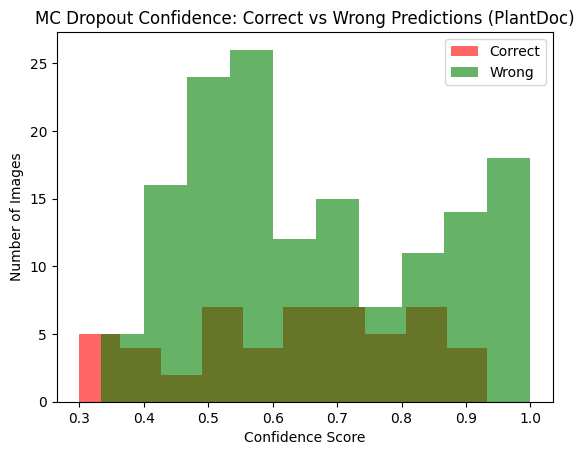

In [30]:
import matplotlib.pyplot as plt

plt.hist(correct_confidences, bins=10, alpha=0.6, label="Correct", color="red")
plt.hist(wrong_confidences, bins=10, alpha=0.6, label="Wrong", color="green")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Images")
plt.title("MC Dropout Confidence: Correct vs Wrong Predictions (PlantDoc)")
plt.legend()
plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# for i in range(0,800,100):  # display 3 random images
#     img = plantdoc_images[i]  # pick from your list, indices 0, 1, 2 for now
#     img = img.permute(1, 2, 0)  # rearrange to [height, width, channels]
#     plt.imshow(img)
#     plt.title(f"Label index: {plantdoc_labels[i]}")
#     plt.show()

In [32]:
from collections import defaultdict

class_correct = defaultdict(int)
class_total = defaultdict(int)

model.eval()
with torch.no_grad():
    for images, labels in plantdoc_dataLoader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)

        for label, pred in zip(labels, predicted):
            label = label.item()
            class_total[label] += 1
            if label == pred.item():
                class_correct[label] += 1

for class_idx in sorted(class_total.keys()):
    class_name = train_data.classes[class_idx]
    acc = class_correct[class_idx] / class_total[class_idx] * 100
    print(f"{class_name}: {acc:.1f}% ({class_correct[class_idx]}/{class_total[class_idx]})")

Pepper__bell___Bacterial_spot: 28.9% (24/83)
Pepper__bell___healthy: 7.1% (3/42)
Potato___Early_blight: 4.7% (8/171)
Potato___Late_blight: 1.4% (3/208)
Tomato_Bacterial_spot: 0.9% (1/110)
Tomato_Early_blight: 10.2% (9/88)
Tomato_Late_blight: 85.6% (95/111)
Tomato_Leaf_Mold: 2.2% (2/91)
Tomato_Septoria_leaf_spot: 32.5% (51/157)
Tomato_Spider_mites_Two_spotted_spider_mite: 0.0% (0/2)
Tomato__Tomato_YellowLeaf__Curl_Virus: 58.8% (140/238)
Tomato__Tomato_mosaic_virus: 1.9% (1/54)
Tomato_healthy: 0.0% (0/52)


In [33]:

# from PIL import Image

# folder_path = "train/Tomato_leaf"
# image_files = os.listdir(folder_path)

# for filename in image_files[:5]:
#     img = Image.open(os.path.join(folder_path, filename))
#     plt.imshow(img)
#     plt.title(f"Label index: {plantdoc_labels[i]}")
#     plt.show()

In [34]:
# import os
# from PIL import Image

# folder_path = "train/Tomato_leaf_bacterial_spot"
# image_files = os.listdir(folder_path)

# for filename in image_files[:5]:
#     img = Image.open(os.path.join(folder_path, filename))
#     display(img)

In [35]:
# import os
# from PIL import Image

# folder_path = "train/Tomato_leaf_late_blight"
# image_files = os.listdir(folder_path)

# for filename in image_files[:5]:
#     img = Image.open(os.path.join(folder_path, filename))
#     display(img)

In [37]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


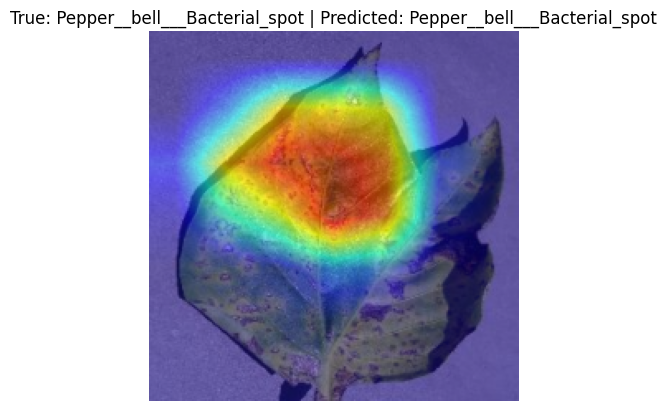

In [41]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

# Step 1: pick the target layer (last conv layer of the frozen backbone)
target_layer = [model.layer4[-1]]

# Step 2: create the Grad-CAM object, pointed at your model and that layer
model.eval()
cam = GradCAM(model=model, target_layers=target_layer)

# Step 3: pick an image to explain — reuse one from val_dataset
image, true_label = val_data[0]
input_tensor = image.unsqueeze(0).to(device)  # add batch dimension
input_tensor.requires_grad = True

# Step 4: run Grad-CAM, targeting the model's own predicted class
with torch.no_grad():
    output = model(input_tensor)
    _, predicted_class = torch.max(output, dim=1)

targets = [ClassifierOutputTarget(predicted_class.item())]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]  # remove batch dimension

# Step 5: prepare the original image for overlay (undo normalization, roughly)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = image.permute(1, 2, 0).numpy()
img_np = std * img_np + mean  # reverse the normalization
img_np = np.clip(img_np, 0, 1)  # keep values in valid displayable range

# Step 6: overlay the heatmap on the original image
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

# Step 7: display everything
true_class_name = train_data.classes[true_label]
predicted_class_name = train_data.classes[predicted_class.item()]

plt.imshow(visualization)
plt.title(f"True: {true_class_name} | Predicted: {predicted_class_name}")
plt.axis("off")
plt.show()

In [45]:
model.eval()
wrong_idx = None

with torch.no_grad():
    for i in range(len(plantdoc_images)):
        img = plantdoc_images[i].unsqueeze(0).to(device)
        output = model(img)
        _, pred = torch.max(output, dim=1)
        if pred.item() != plantdoc_labels[i]:
            wrong_idx = i
            break

print(f"Found a wrong prediction at index {wrong_idx}")

Found a wrong prediction at index 0


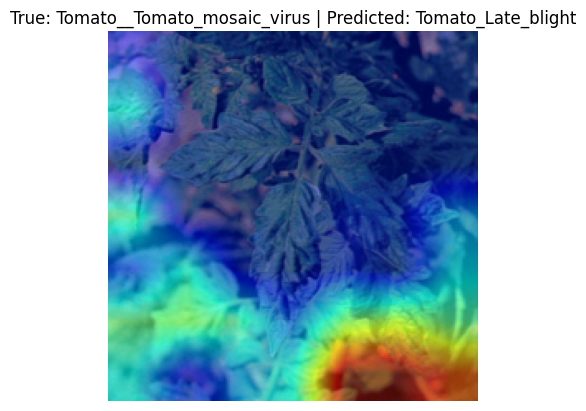

In [46]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

# Step 1: target layer
target_layer = [model.layer4[-1]]

# Step 2: create Grad-CAM object
model.eval()
cam = GradCAM(model=model, target_layers=target_layer)

# Step 3: pick the wrong PlantDoc image we found
image = plantdoc_images[wrong_idx]
true_label = plantdoc_labels[wrong_idx]
input_tensor = image.unsqueeze(0).to(device)  # add batch dimension
input_tensor.requires_grad = True

# Step 4: run Grad-CAM, targeting the model's predicted class
with torch.no_grad():
    output = model(input_tensor)
    _, predicted_class = torch.max(output, dim=1)

targets = [ClassifierOutputTarget(predicted_class.item())]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]

# Step 5: undo normalization for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = image.permute(1, 2, 0).numpy()
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

# Step 6: overlay heatmap
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

# Step 7: display
true_class_name = train_data.classes[true_label]
predicted_class_name = train_data.classes[predicted_class.item()]

plt.imshow(visualization)
plt.title(f"True: {true_class_name} | Predicted: {predicted_class_name}")
plt.axis("off")
plt.show()